In [1]:
import copy
import numpy as np
import pandas as pd
import uproot as ur
from scipy.stats import norm
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
from matplotlib.ticker import NullFormatter, AutoMinorLocator, MultipleLocator, FuncFormatter

# setting random seed for reproducibility
np.random.seed(2150237)

In [2]:
# function to plot and count particles under the peack 
def particle_count( df, particle, key = 'fM', units = 'given units', steps = 200, bins = None, 
                    ax = None, title = None, par = None, peack_region = None) :

    p_name = r"$D_0$" if particle == 'D0' else r"$\Lambda_C^{+}$"
    
     # extrapolation the chosen column to display and extrapolating chosen labels    
    X = df[ key ].to_numpy()
    if bins is None :
        max_x = X.max()
        min_x = X.min()
        bins  = np.linspace( min_x, max_x, steps  )
    hist, bin_edges = np.histogram( X, bins = bins )
    errors = np.sqrt( hist )
    errors = np.clip( errors, 1, None )
    x_values = ( bin_edges[:-1] + bin_edges[1:] ) / 2.
    bin_w = bin_edges[ 2 ] - bin_edges[ 1 ]

    def fit_function( x, A, mu, sigma, a, b, c ) :
        signal     = norm.pdf( x, loc = mu, scale = sigma )
        background = a * x**2 + b * x + c
        return A * signal + background

    # if not provided, using an ansatz to optimize the fit search
    if par is None :
        mu_0    = 1.86484 if particle == 'D0' else 2.28646 # PDG mass (GeV) 
        sigma_0 = 0.05 if particle == 'D0' else 0.02 # MC mass sigma (GeV)
        # using backgound interpolation as ansatz for the parabolic background
        # for the background we exclude the peack region, 
        # if not provided a 3 sigma region around the peack is used
        if peack_region is None :
            peack_region = ( mu_0 - 3.0 * sigma_0, mu_0 + 3.0 * sigma_0 )
        bg_mask = ( x_values < peack_region[0] ) | ( x_values > peack_region[1] )
        # fit background with a polynomial fit
        a_0, b_0, c_0 = np.polyfit( x = x_values[ bg_mask ], y = hist[ bg_mask ],
                                    w = 1.0 / errors[ bg_mask ], deg = 2 )
        # find the point corresponding to the expected center
        mu_bin = np.digitize( mu_0, bin_edges )
        mu_A = hist[ mu_bin ]
        mu_x = x_values[ mu_bin ]
        A_0 = np.abs( mu_A - ( c_0 + b_0 * mu_x + a_0 * mu_x**2 ) ) / norm.pdf( mu_x, loc = mu_0, scale = sigma_0 )
        par = [
                A_0,     # 0: A
                mu_0,    # 1: mu
                sigma_0, # 2: sigma
                a_0,     # 3: a
                b_0,     # 4: b
                c_0      # 5: c
                ]

    # setting parameter bounds to improve interpolation
    par_lb = [
                0.0,               # 0: A > 0
                x_values.min(),    # 1: mu in range
                1e-5,              # 2: sigma not expected to be lower than PDG precision
                -np.inf,           # 3: a no limit
                -np.inf,           # 4: b no limit
                0.0                # 5: c > 0 (costant bg should be positive)
                ]
    x_range = x_values.max() - x_values.min() 
    A_max = hist.max() * x_range
    par_ub = [
                A_max,             # 0: A < Fig area, seems reasonable
                x_values.max(),    # 1: mu in range
                x_range,           # 2: sigma not expected to be grater than the fig range
                np.inf,            # 3: a no limit
                np.inf,            # 4: b no limit
                hist.max() * 100   # 5: c < 100 * max y, seems reasonable
                ]
    try :
        fit_results = curve_fit(
                                f       = fit_function,
                                xdata   = x_values,
                                ydata   = hist,
                                sigma   = errors,
                                p0      = par,
                                bounds  = (par_lb, par_ub),
                                maxfev  = 1500 )
    
        fit_par = fit_results[0]
        A_error = np.sqrt( fit_results[1][0, 0] )
        mass_error = np.sqrt( fit_results[0][2] / hist.shape[0] )
    except RuntimeError as e:
        print(f"Fit failed:\n{e}")
        print("Returning initial parameters")
        fit_par = np.array(par)
        A_error = 0.0
        mass_error = 0.0
    
    A_fit, mu_fit, sigma_fit, a_fit, b_fit, c_fit = fit_par
    # particle counting from the Gaussian
    p_counts = ( A_fit * ( norm.cdf( bins[-1], loc = mu_fit, scale = sigma_fit ) - norm.cdf( bins[0], loc = mu_fit, scale = sigma_fit ) ) ) / bin_w
    # particle count error with error propagation, assuming CDF approx 1
    p_error = A_error / bin_w
    
    do_show = False
    if ax is None :
        do_show = True
        fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize=( 12, 8 ) )
    ax.errorbar( x = x_values , y = hist, yerr = errors, alpha=0.85, color='black', ecolor='gray', elinewidth=0.75, fmt='o', markersize=2.5, label = 'data' )
    # Plot fitted curve (Parabolic background model).
    ax.plot( x_values, fit_function( x_values, *fit_par), color='darkred', alpha = 0.75, linewidth=1.5, label='data fit with parabolic background')
    # Plotting the theoretical and interpolated value for the particle
    ax.axvline( x = mu_0, color = 'midnightblue', ls = '--', alpha = 0.65, label = f'theoretical {p_name} mass' )
    ax.axvline( x = mu_fit, color = 'darkred', ls = '--', alpha = 0.65, label = f'computed {p_name} mass' )
    # ax.set_xlim( min_x, max_x )
    ax.xaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.yaxis.set_minor_locator(AutoMinorLocator( 4 ))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    if title is None :
        ax.set_title( f"{key} distribution for selected data" )
    else :
        ax.set_title( title )
    ax.set_xlabel( f"{key} [{units}]")
    ax.set_ylabel( f"Entries / {bin_w:.2e} {units}")    
    ax.table( 
        cellText = [[f"{X.shape[0]}"], [f"{X[X < bin_edges[0] ].shape[0]}"], [f"{X[X > bin_edges[-1] ].shape[0]}"],
                    [f"{p_counts:.0f}"], [f"{mu_fit:.3f} {units}"], [f"{sigma_fit:.3f} {units}"] ],
        rowLabels = [ 'Entries', 'Underflow', 'Overflow', ( p_name + ' Count'), 'Mean', 'Std Dev'],
        bbox = [0.77, 0.75, 0.15, 0.22 ],
        edges = 'open',
        rowLoc = 'left',
        )
    ax.legend( loc = 'lower left')
    if do_show : plt.show()
    fit_par = np.append( fit_par, [p_counts, p_error, mass_error] )
    return fit_par

In [3]:
# Plotting obtained particles and efficiencies for different Pt ranges
# excluding low pt region in which we were not able to get results (pt_treshold)
def results_draw( p_name, pt_treshold, results_df ): 
    
    # retrieving the data
    pt_intervals   = results_df[ 'Pt' ].iloc[ pt_treshold : ].to_numpy()
    particles_ct   = results_df[ 'Raw Yield' ].iloc[ pt_treshold : ].to_numpy()
    s_particles_ct = results_df[ 'Sigma Raw Yield' ].iloc[ pt_treshold : ].to_numpy()
    p_efficiency   = results_df[ 'Efficiency' ].iloc[ pt_treshold : ].to_numpy()
    s_p_efficiency = results_df[ 'Sigma Efficiency' ].iloc[ pt_treshold : ].to_numpy()
    b_efficiency   = results_df[ 'Beauty Efficiency' ].iloc[ pt_treshold : ].to_numpy()
    s_b_efficiency = results_df[ 'Sigma Beauty Efficiency' ].iloc[ pt_treshold : ].to_numpy()
    
    N = 3
    x = np.arange( pt_intervals.shape[0] )
    # define color and marker palette
    colors  = plt.get_cmap( 'jet' )( np.arange( 3 ) / ( N - 0.99 ) )
    markers = [ "*", "P", "h", "s", "d", "p", "8", "D", "v", "^", "<", ">" ]
    
    fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize = ( 12, 6 ) )
    
    ax.errorbar( x = x, y = p_efficiency, yerr = s_p_efficiency, marker = markers[1],
                 color = colors[1], label = f'Prompt {p_name} efficiency', alpha = 0.75, 
                 markersize = 6, linestyle = '-.', capsize = 3, lw = 0.75 )
    ax.errorbar( x = x, y = b_efficiency, yerr = s_b_efficiency, marker = markers[0], 
                 color = colors[0], label = f'Beauty {p_name} efficiency', alpha = 0.75,
                 markersize = 6, linestyle = '-.', capsize = 3, lw = 0.75 )
    ax.set_ylim( 0.0, p_efficiency.max()*1.2 )
    ax.xaxis.set_major_locator(MultipleLocator( 1 ))
    ax.yaxis.set_minor_locator( AutoMinorLocator( 5 ) )
    ax.set_xticks( x, labels = pt_intervals )
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    ax.set_title( f"{p_name} raw yield and efficiency across Pt ranges")
    ax.set_xlabel( r"$P_T$ range")
    ax.set_ylabel( "Efficiency", color='black')
    ay = ax.twinx()        
    ay.errorbar( x = x, y = particles_ct, yerr = s_particles_ct, marker = markers[2], 
                 color = colors[2], label = f'Counted {p_name}', alpha = 0.75, 
                 markersize = 6, linestyle = '-.', capsize = 3, lw = 0.75 )
    ay.set_ylabel( 'Raw Yield', color = colors[2] )
    ay.set_ylim( 0, int( particles_ct.max()*1.15 ) )
    ay.tick_params( axis='y', labelcolor=colors[ 2 ] )
    ay.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5, color = colors[2] )
    ay.tick_params( which = 'minor', direction = 'in', length = 5, width = 1, color = colors[2] )
    ay.yaxis.set_minor_locator( AutoMinorLocator( 5 ) )
    ax.legend( loc = 'upper left')
    ay.legend( loc = 'center left')
    fig.tight_layout()  
    plt.show()

In [4]:
# 1.4) Divide into Pt regions, as decided a priori
DZ_fPt_Train_Ranges = [ (0, 2), (2, 3.2), (3.2, 5), (5, 20) ]
DZ_fPt_Extract_Ranges = [ [(0, 0.7), (0.7, 1), (1, 1.25), (1.25, 1.5), (1.5, 1.75), (1.75, 2)], [(2, 2.2), (2.2, 2.5), (2.5, 2.8), (2.8, 3.2)], [(3.2, 4.2), (4.2, 5)], [(5, 20)] ]
LC_fPt_Train_Ranges = [ (0, 3.2), (3.2, 5), (5, 20)]
LC_fPt_Extract_Ranges = [ [(0, 2.2), (2.2, 2.35), (2.35, 2.5), (2.5, 2.7), (2.7, 2.9), (2.9, 3.2)], [(3.2, 3.4), (3.4, 3.55), (3.55, 3.85), (3.85, 4.2), (4.2, 5)], [(5, 20)]]

# also the mass interval filter can be used, based on MC
# DZ_fM_cut = [ (1.66, 2.07), (1.66, 2.07), (1.66, 2.07), (1.66, 2.07) ]
DZ_fM_cut = [ (1.67, 2.06), (1.67, 2.06), (1.67, 2.06), (1.67, 2.06) ]
# LC_fM_cut = [ (2.0, 2.5), (1.9, 2.68), (1.9, 2.7) ]
LC_fM_cut = [ (2.1, 2.55), (2.1, 2.55), (2.0, 2.6) ]

# cut for what we can use as BG, based on the MC graphs (these are the peacks)
DZ_fM_peack = [ (1.815, 1.915), (1.805, 1.925), (1.805, 1.935), (1.795, 1.945) ]
LC_fM_peack = [ (2.26, 2.31), (2.26, 2.31), (2.26, 2.31) ]

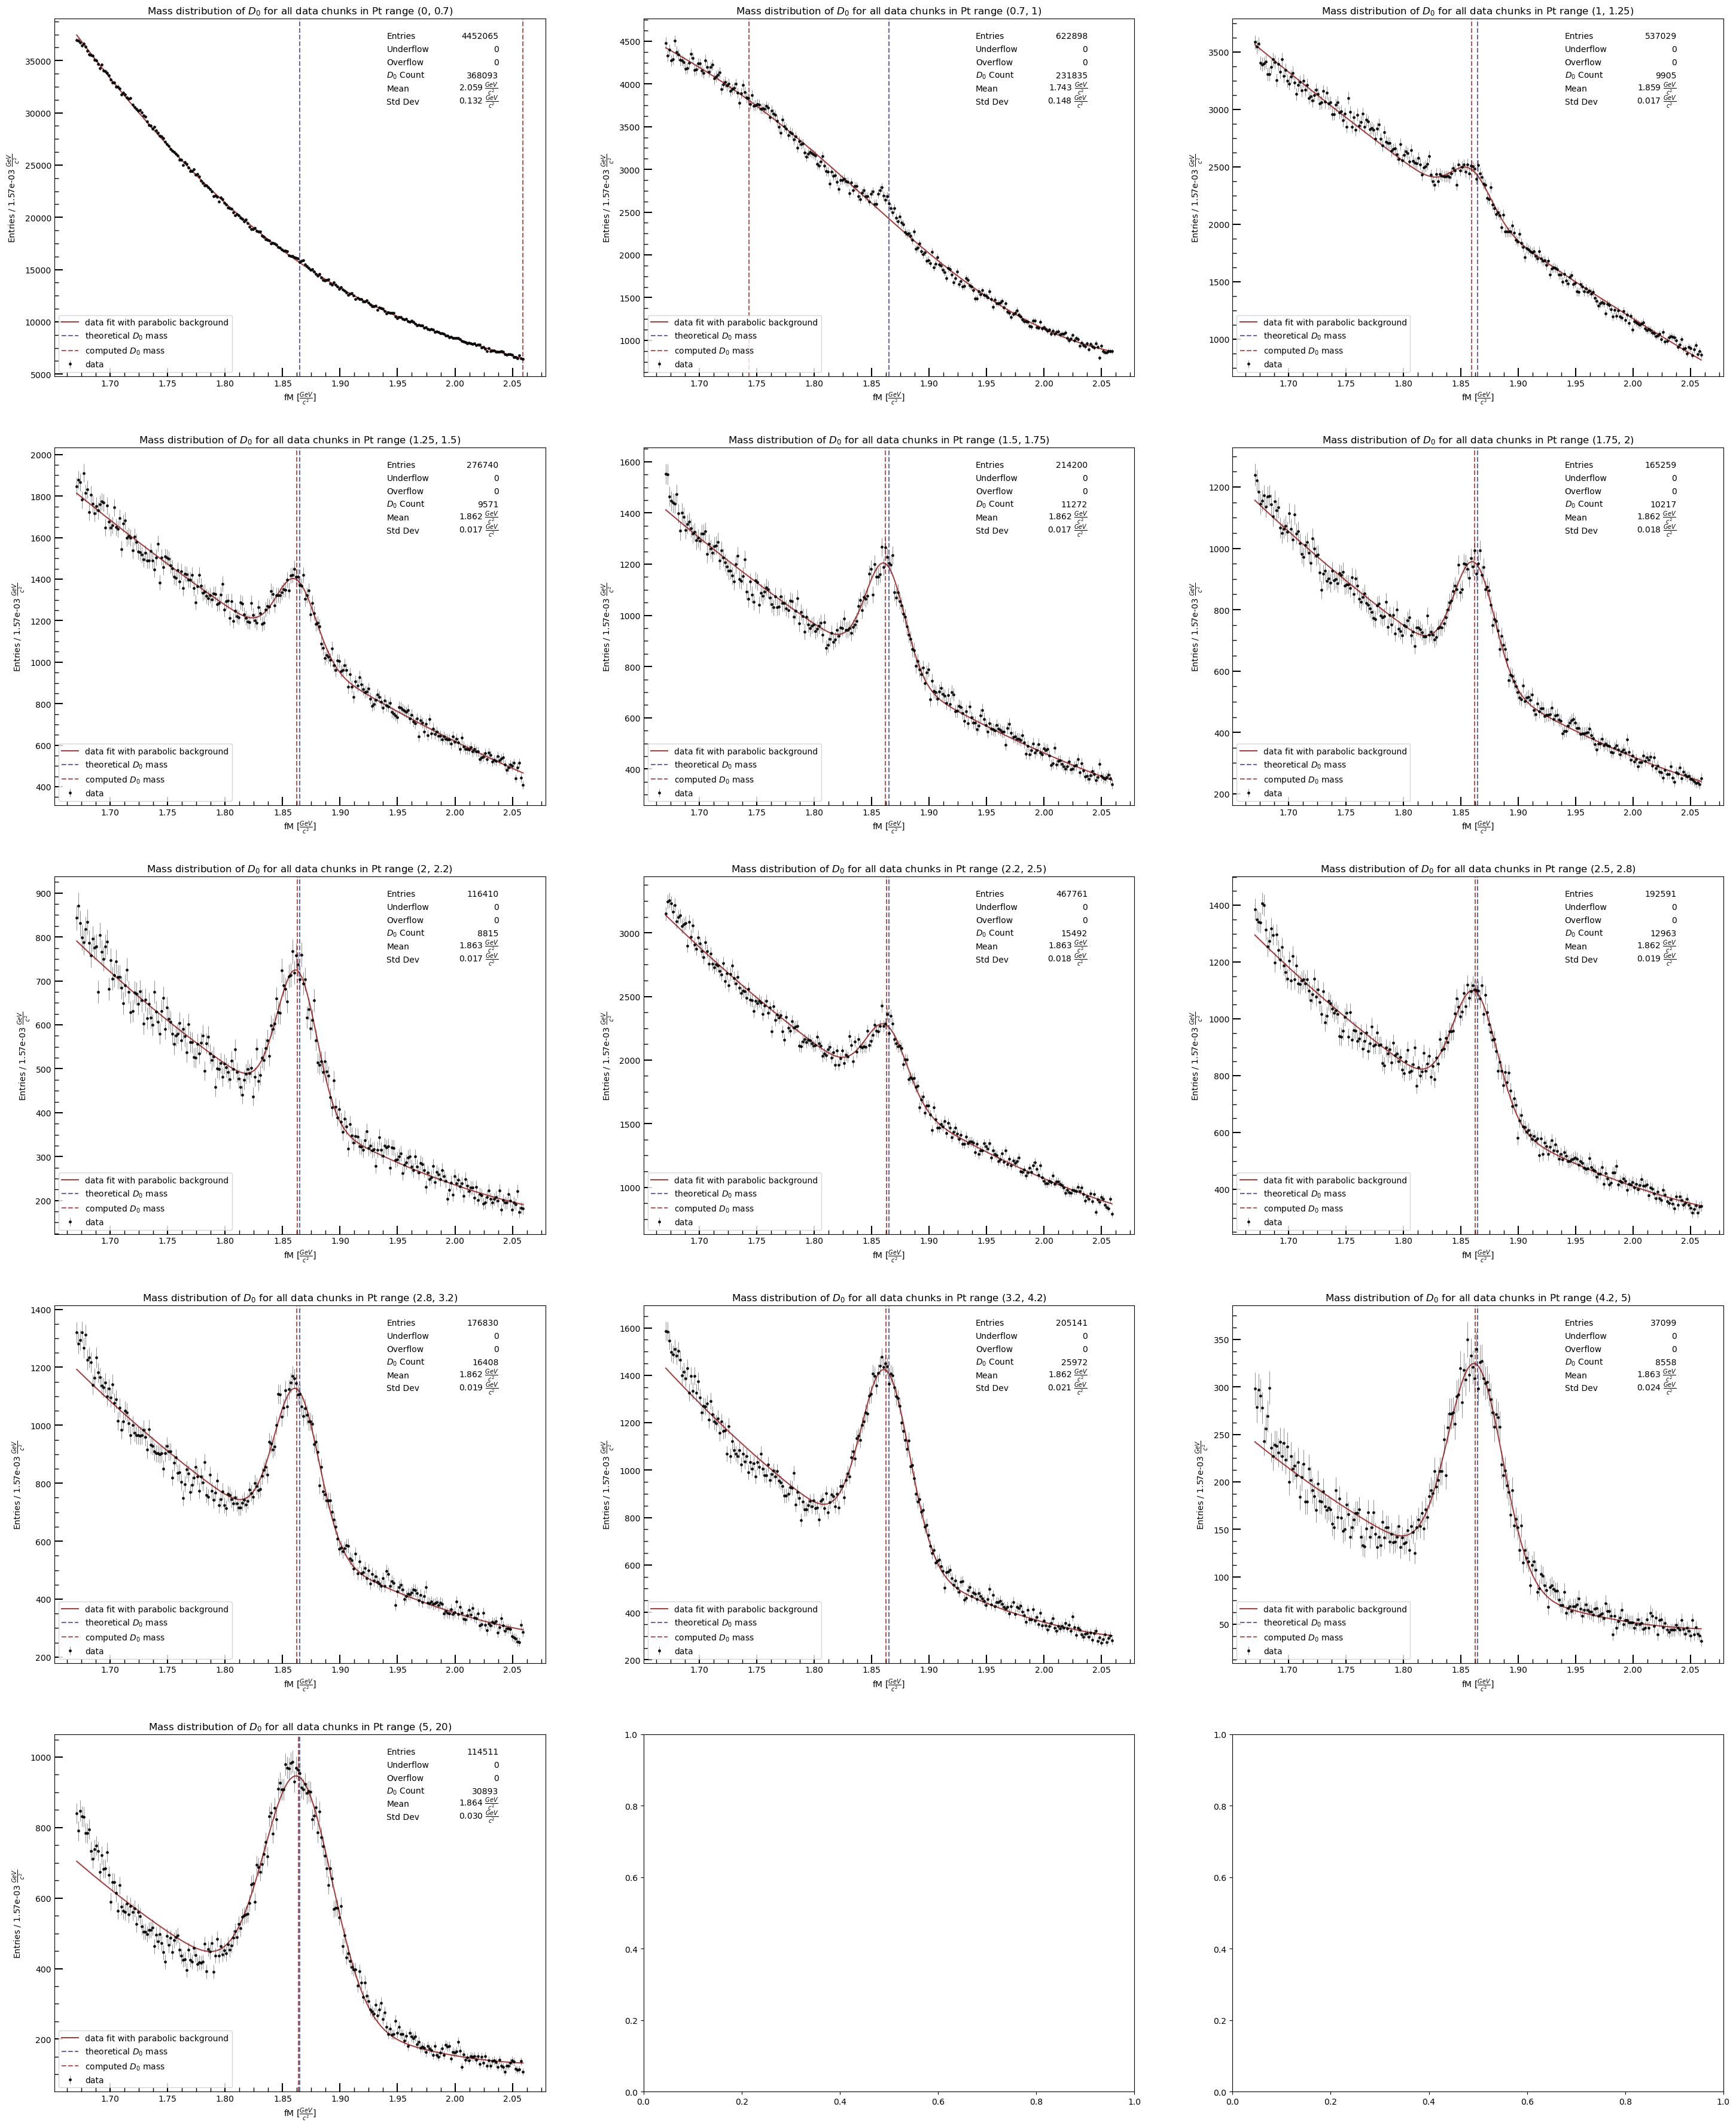

In [5]:

particle  = 'D0'
# particle  = 'LC'

p_name = r"$D_0$" if particle == 'D0' else r"$\Lambda_C^{+}$"
pt_range = DZ_fPt_Train_Ranges if particle == 'D0' else LC_fPt_Train_Ranges
sub_pt_range = DZ_fPt_Extract_Ranges if particle == 'D0' else LC_fPt_Extract_Ranges
M_cut = DZ_fM_cut if particle == 'D0' else LC_fM_cut
peack_cut = DZ_fM_peack if particle == 'D0' else LC_fM_peack

# cut_index = 0
# cut_subindex = 0
# pt_int = sub_pt_range[ cut_index ][ cut_subindex ]

# making all fit into a single plot
figures = sum( [ len( main_cut ) for main_cut in sub_pt_range ] )
cols = 3
rows = figures // cols + ( ( figures % cols ) > 0 )
i = 0
# this always gives a 2d array for axs
fig, axs = plt.subplots( nrows = rows, ncols = cols, figsize=( 12*cols, 9*rows ), squeeze = False )

results = { 'Pt' : [], 
            'Raw Yield' : [], 
            'Sigma Raw Yield' : [], 
            'Mass' : [], 
            'Sigma' : [], 
            'Pull' : [], 
            'Efficiency' : [], 
            'Sigma Efficiency' : [], 
            'Beauty Efficiency' : [],
            'Sigma Beauty Efficiency' : [] }

for cut_index, main_cut in enumerate( sub_pt_range ) :
    property_file = f"/mnt/CandidateReducedDF/XGBoost_Cuts_{particle}_Pt_Interval_{cut_index}.csv"
    # property_file = f"./selected_df/XGBoost_Cuts_{particle}_Pt_Interval_{cut_index}.csv"
    property_df = pd.read_csv( property_file )
    
    for cut_subindex, pt_int in enumerate( main_cut ) :

        output_file = f"/mnt/CandidateReducedDF/Selected_{particle}_Pt_Int_{cut_index}_Sub_Pt_Int_{cut_subindex}.csv"
        # output_file = f"./selected_df/Selected_{particle}_Pt_Int_{cut_index}_Sub_Pt_Int_{cut_subindex}.csv"   
        
        n_bin = 250
        bins  = np.linspace( M_cut[cut_index][0], M_cut[cut_index][1], n_bin ) # bin edges
        # histo = np.zeros( ( len( train_lab ), ( n_bin - 1 ) ) )
        
        # print( f"Pt interval used: {pt_int}")
        # all data plot
        bins  = np.linspace( M_cut[cut_index][0], M_cut[cut_index][1], 250 ) # bin edges
        
        data = pd.read_csv( output_file )

        n_col = i % cols
        n_row = i // cols
        ax = axs[ n_row ][ n_col ]

        fit_par = particle_count( data, particle, key = 'fM', units = r'$\frac{GeV}{c^2}$', ax = ax, peack_region = peack_cut[cut_index],
                    bins = bins, title = f"Mass distribution of {p_name} for all data chunks in Pt range {pt_int}" )
        
        results[ 'Pt' ].append( copy.deepcopy( pt_int ) )
        results[ 'Raw Yield' ].append( copy.deepcopy( np.round( fit_par[6] ) ) )
        results[ 'Sigma Raw Yield' ].append( copy.deepcopy( np.round( fit_par[7] ) ) )
        results[ 'Mass' ].append( copy.deepcopy( np.round( fit_par[1], decimals = 3 ) ) )
        results[ 'Sigma' ].append( copy.deepcopy( np.round( fit_par[2], decimals = 3 ) ) )
        
        mu_0    = 1.86484 if particle == 'D0' else 2.28646 # PDG mass (GeV) 
        sigma_0 = 0.00005 if particle == 'D0' else 0.00014 # PDG mass sigma (GeV)

        # adding the pull, the distance between theoretical and experimental mass in sigma units
        results[ 'Pull' ].append( np.round( np.abs( fit_par[1] - mu_0 ) / np.hypot( fit_par[8], sigma_0 ) , decimals = 2 ) )
        # adding efficiency computed on MC for compacting dataframe
        results[ 'Efficiency' ].append( copy.deepcopy( np.round( property_df[ 'Efficiency' ].iloc[ cut_subindex ], decimals = 4 ) ) )
        results[ 'Sigma Efficiency' ].append( copy.deepcopy( np.round( property_df[ 'Sigma Efficiency' ].iloc[ cut_subindex ], decimals = 4 ) ) )
        results[ 'Beauty Efficiency' ].append( copy.deepcopy( np.round( property_df[ 'Beauty Efficiency' ].iloc[ cut_subindex ], decimals = 4 ) ) )
        results[ 'Sigma Beauty Efficiency' ].append( copy.deepcopy( np.round( property_df[ 'Sigma Beauty Efficiency' ].iloc[ cut_subindex ], decimals = 4 ) ) )
        
        i += 1
        
        del data

results_df = pd.DataFrame( results )
plt.show()

In [6]:
# this factor should be used to consider particle and antiparticle
correction_factor = 2.

# computing corrected yield and its error
results_df[ 'Corrected Yield' ] = np.round( results_df[ 'Raw Yield' ] / results_df[ 'Efficiency' ] / correction_factor )
results_df[ 'Sigma Corrected Yield' ] = np.round( results_df[ 'Corrected Yield' ] * np.hypot( ( results_df[ 'Sigma Efficiency' ] /results_df[ 'Efficiency' ] ), ( results_df[ 'Sigma Raw Yield' ] / results_df[ 'Raw Yield' ] ) ) )
# saving results
output_file = f"/mnt/CandidateReducedDF/Particle_{particle}_Counts.csv"
# output_file = f"./selected_df/Particle_{particle}_Counts.csv"
results_df.to_csv( output_file, mode = 'w', header = True )
results_df

,Pt,Raw Yield,Sigma Raw Yield,Mass,Sigma,Pull,Efficiency,Sigma Efficiency,Beauty Efficiency,Sigma Beauty Efficiency,Corrected Yield,Sigma Corrected Yield
0,"(0, 0.7)",368093.0,1193243.0,2.059,0.132,8.45,0.0213,0.0006,0.0209,0.0008,8640681.0,28011457.0
1,"(0.7, 1)",231835.0,379317.0,1.743,0.148,4.98,0.0245,0.0006,0.0197,0.0008,4731327.0,7742031.0
2,"(1, 1.25)",9905.0,615.0,1.859,0.017,0.65,0.0316,0.0007,0.0193,0.0009,156725.0,10332.0
3,"(1.25, 1.5)",9571.0,359.0,1.862,0.017,0.34,0.0358,0.0007,0.0220,0.0009,133673.0,5654.0
4,"(1.5, 1.75)",11272.0,336.0,1.862,0.017,0.35,0.0458,0.0007,0.0286,0.0009,123057.0,4122.0
5,"(1.75, 2)",10217.0,267.0,1.862,0.018,0.34,0.0477,0.0007,0.0240,0.0009,107096.0,3210.0
6,"(2, 2.2)",8815.0,273.0,1.863,0.017,0.28,0.0620,0.0009,0.0312,0.0011,71089.0,2431.0
7,"(2.2, 2.5)",15492.0,579.0,1.863,0.018,0.23,0.0841,0.0007,0.0353,0.0009,92105.0,3527.0
8,"(2.5, 2.8)",12963.0,362.0,1.862,0.019,0.28,0.0888,0.0008,0.0349,0.0010,72990.0,2142.0
9,"(2.8, 3.2)",16408.0,420.0,1.862,0.019,0.29,0.1103,0.0007,0.0478,0.0009,74379.0,1962.0


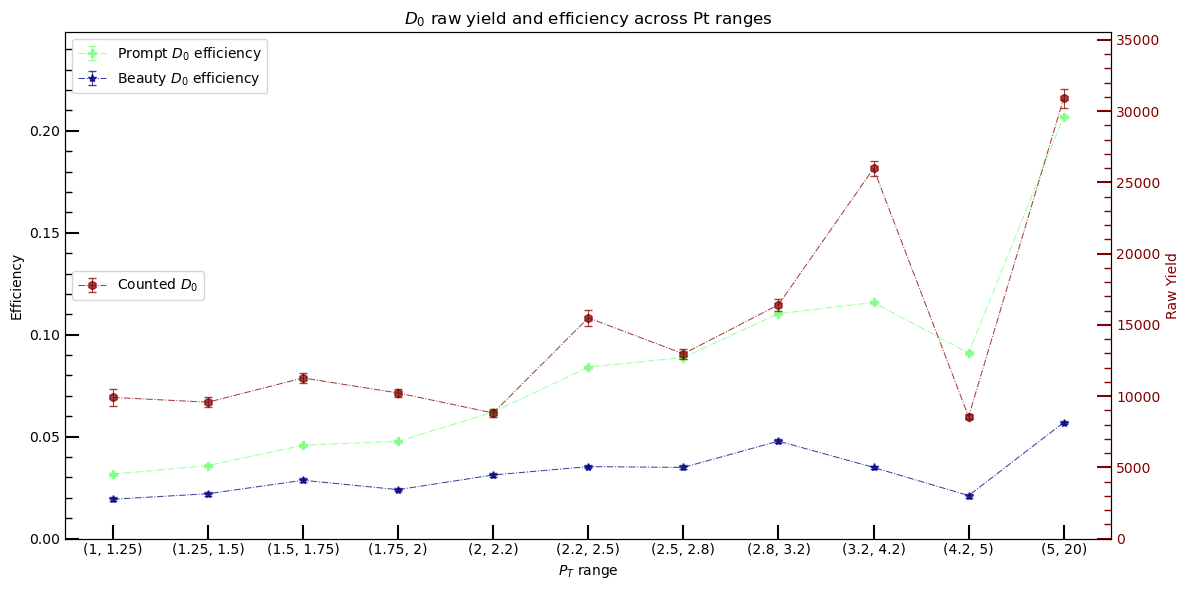

In [7]:
results_draw( p_name = p_name, pt_treshold = 2, results_df = results_df )

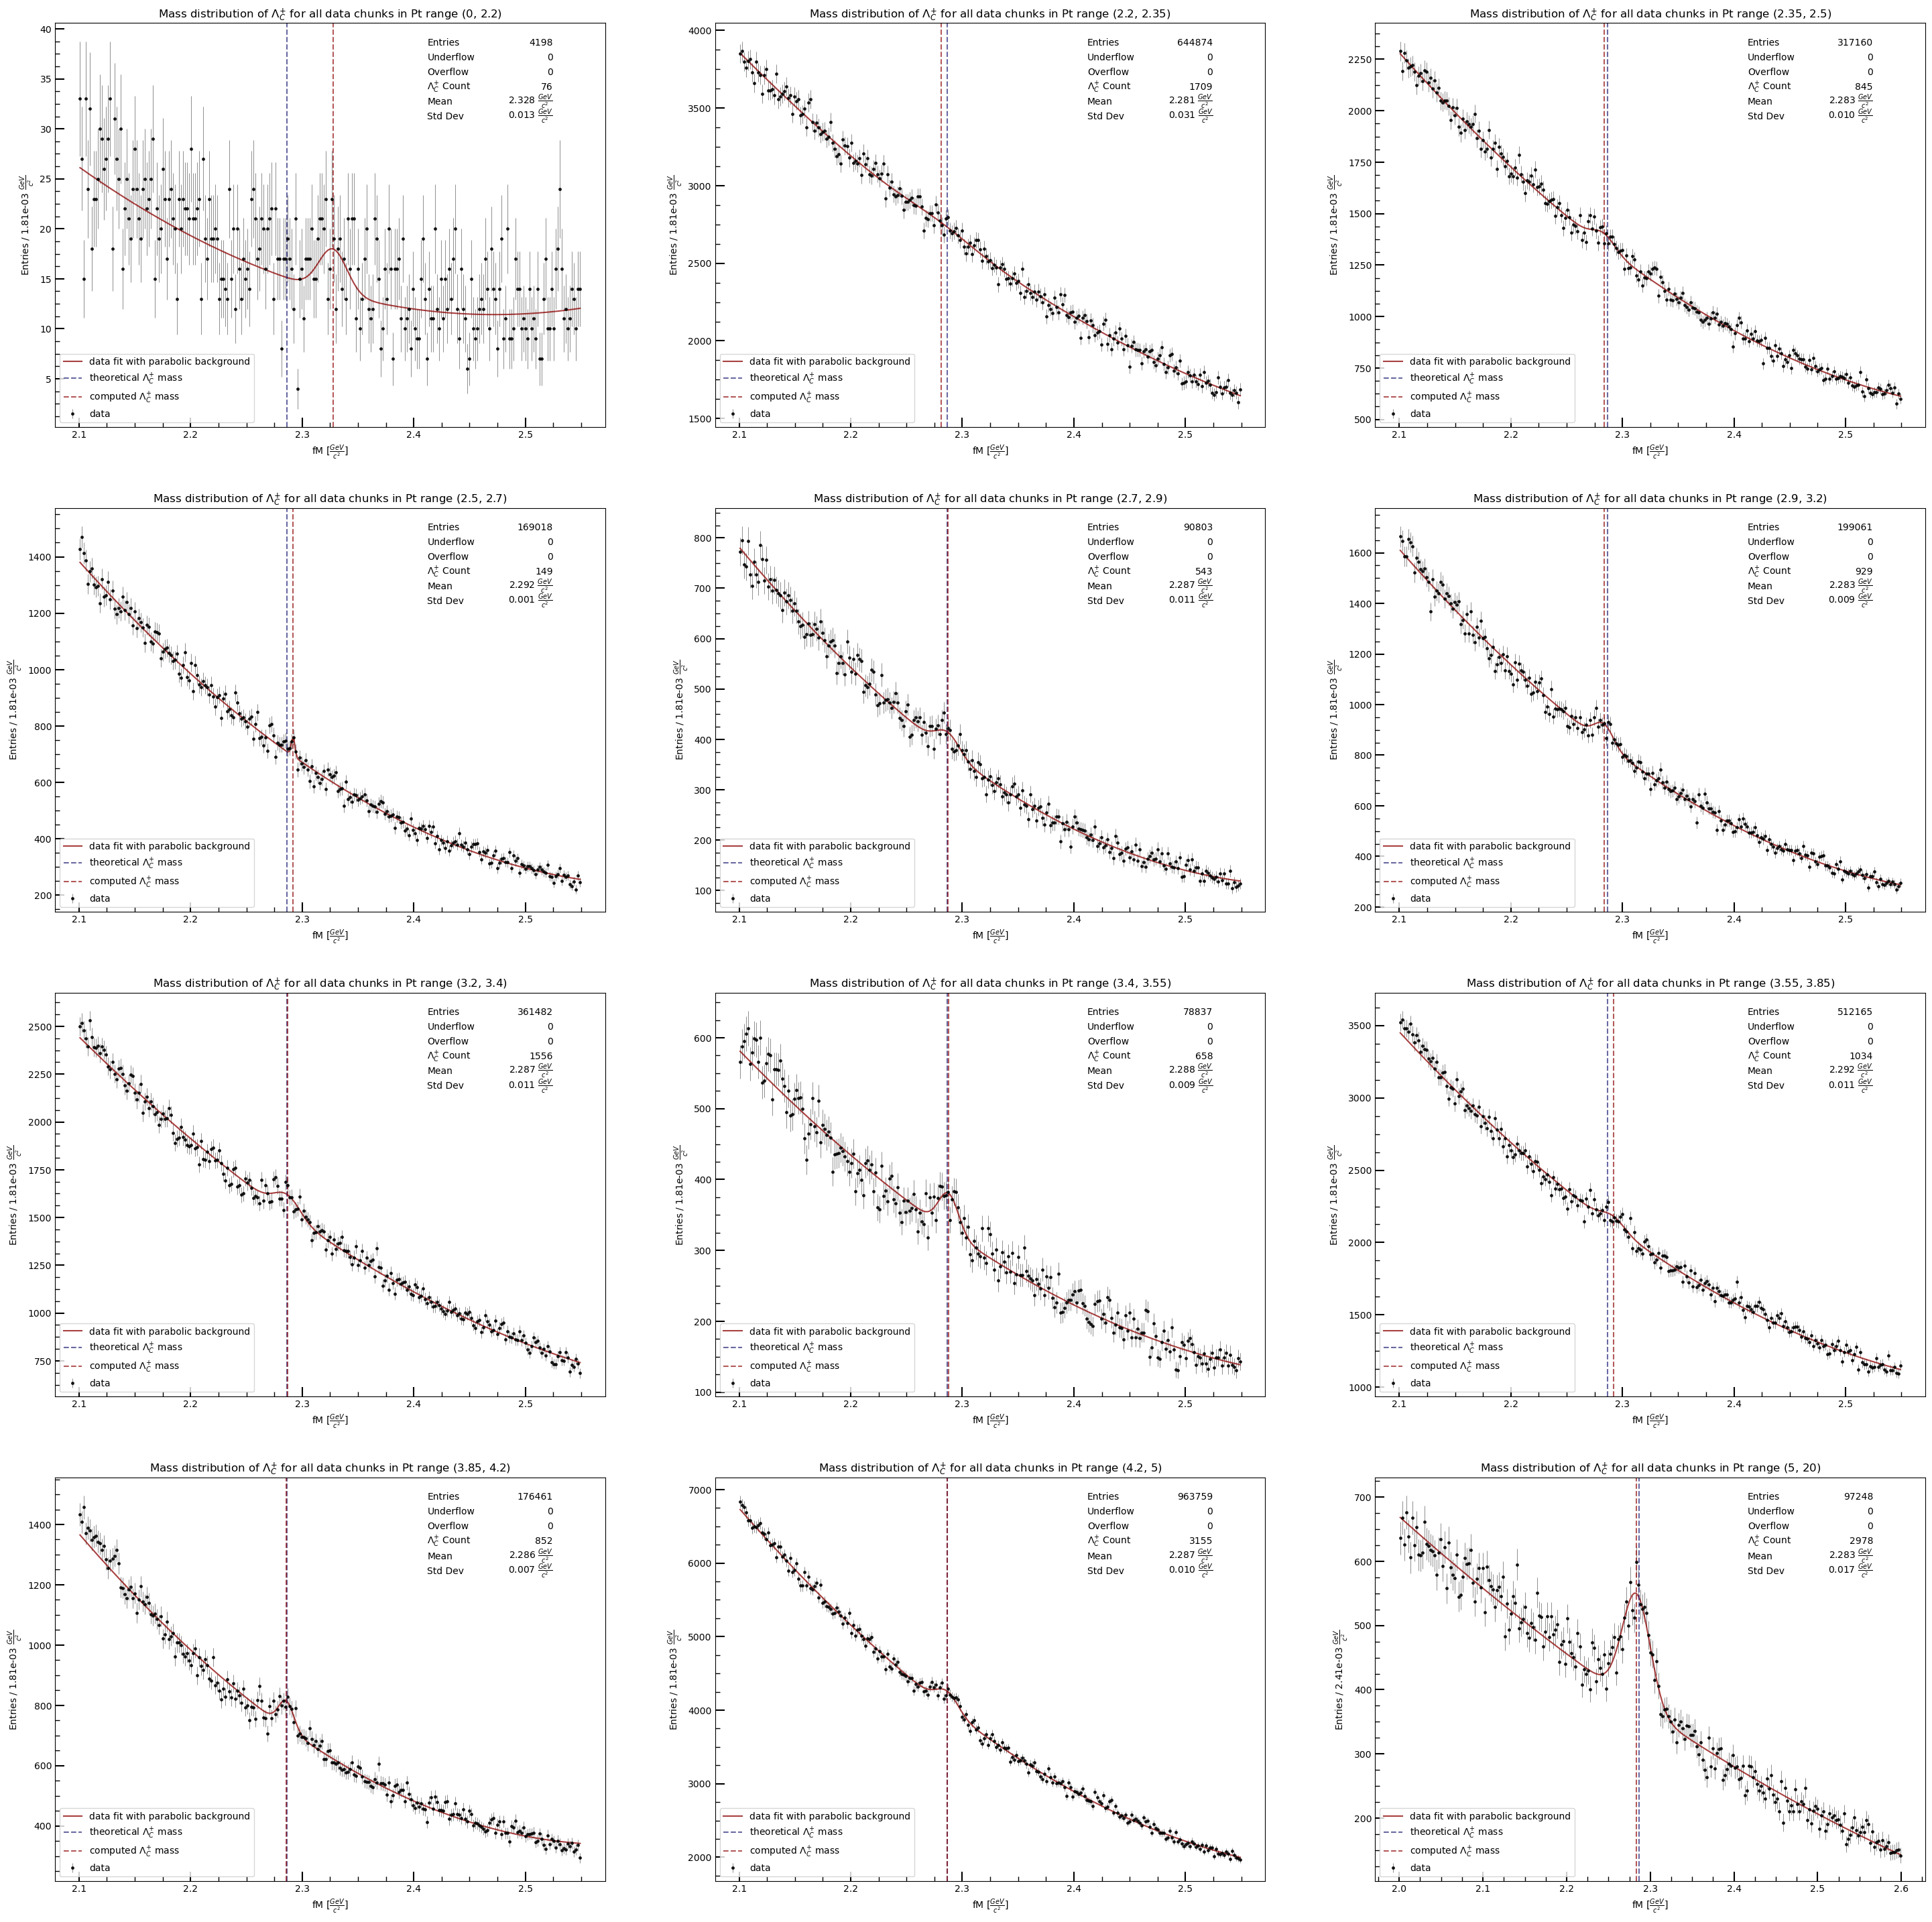

In [8]:

# particle  = 'D0'
particle  = 'LC'

p_name = r"$D_0$" if particle == 'D0' else r"$\Lambda_C^{+}$"
pt_range = DZ_fPt_Train_Ranges if particle == 'D0' else LC_fPt_Train_Ranges
sub_pt_range = DZ_fPt_Extract_Ranges if particle == 'D0' else LC_fPt_Extract_Ranges
M_cut = DZ_fM_cut if particle == 'D0' else LC_fM_cut
peack_cut = DZ_fM_peack if particle == 'D0' else LC_fM_peack

# cut_index = 0
# cut_subindex = 0
# pt_int = sub_pt_range[ cut_index ][ cut_subindex ]

# making all fit into a single plot
figures = sum( [ len( main_cut ) for main_cut in sub_pt_range ] )
cols = 3
rows = figures // cols + ( ( figures % cols ) > 0 )
i = 0
# this always gives a 2d array for axs
fig, axs = plt.subplots( nrows = rows, ncols = cols, figsize=( 12*cols, 9*rows ), squeeze = False )

results = { 'Pt' : [], 
            'Raw Yield' : [], 
            'Sigma Raw Yield' : [], 
            'Mass' : [], 
            'Sigma' : [], 
            'Pull' : [], 
            'Efficiency' : [], 
            'Sigma Efficiency' : [], 
            'Beauty Efficiency' : [],
            'Sigma Beauty Efficiency' : []}

for cut_index, main_cut in enumerate( sub_pt_range ) :
    property_file = f"/mnt/CandidateReducedDF/XGBoost_Cuts_{particle}_Pt_Interval_{cut_index}.csv"
    # property_file = f"./selected_df/XGBoost_Cuts_{particle}_Pt_Interval_{cut_index}.csv"
    property_df = pd.read_csv( property_file )
    
    for cut_subindex, pt_int in enumerate( main_cut ) :

        output_file = f"/mnt/CandidateReducedDF/Selected_{particle}_Pt_Int_{cut_index}_Sub_Pt_Int_{cut_subindex}.csv"
        # output_file = f"./selected_df/Selected_{particle}_Pt_Int_{cut_index}_Sub_Pt_Int_{cut_subindex}.csv"   
        
        n_bin = 250
        bins  = np.linspace( M_cut[cut_index][0], M_cut[cut_index][1], n_bin ) # bin edges
        # histo = np.zeros( ( len( train_lab ), ( n_bin - 1 ) ) )
        
        # print( f"Pt interval used: {pt_int}")
        # all data plot
        bins  = np.linspace( M_cut[cut_index][0], M_cut[cut_index][1], 250 ) # bin edges
        
        data = pd.read_csv( output_file )

        n_col = i % cols
        n_row = i // cols
        ax = axs[ n_row ][ n_col ]

        fit_par = particle_count( data, particle, key = 'fM', units = r'$\frac{GeV}{c^2}$', ax = ax, peack_region = peack_cut[cut_index],
                    bins = bins, title = f"Mass distribution of {p_name} for all data chunks in Pt range {pt_int}" )
        
        results[ 'Pt' ].append( copy.deepcopy( pt_int ) )
        results[ 'Raw Yield' ].append( copy.deepcopy( np.round( fit_par[6] ) ) )
        results[ 'Sigma Raw Yield' ].append( copy.deepcopy( np.round( fit_par[7] ) ) )
        results[ 'Mass' ].append( copy.deepcopy( np.round( fit_par[1], decimals = 3 ) ) )
        results[ 'Sigma' ].append( copy.deepcopy( np.round( fit_par[2], decimals = 3 ) ) )
        
        mu_0    = 1.86484 if particle == 'D0' else 2.28646 # PDG mass (GeV) 
        sigma_0 = 0.00005 if particle == 'D0' else 0.00014 # PDG mass sigma (GeV)

        # adding the pull, the distance between theoretical and experimental mass in sigma units
        results[ 'Pull' ].append( np.round( np.abs( fit_par[1] - mu_0 ) / np.hypot( fit_par[8], sigma_0 ) , decimals = 2 ) )
        # adding efficiency computed on MC for compacting dataframe
        results[ 'Efficiency' ].append( copy.deepcopy( np.round( property_df[ 'Efficiency' ].iloc[ cut_subindex ], decimals = 4 ) ) )
        results[ 'Sigma Efficiency' ].append( copy.deepcopy( np.round( property_df[ 'Sigma Efficiency' ].iloc[ cut_subindex ], decimals = 4 ) ) )
        results[ 'Beauty Efficiency' ].append( copy.deepcopy( np.round( property_df[ 'Beauty Efficiency' ].iloc[ cut_subindex ], decimals = 4 ) ) )
        results[ 'Sigma Beauty Efficiency' ].append( copy.deepcopy( np.round( property_df[ 'Sigma Beauty Efficiency' ].iloc[ cut_subindex ], decimals = 4 ) ) )
        i += 1
        
        del data

results_df = pd.DataFrame( results )
plt.show()

In [9]:
# computing corrected yield and its error
results_df[ 'Corrected Yield' ] = np.round( results_df[ 'Raw Yield' ] / results_df[ 'Efficiency' ] )
results_df[ 'Sigma Corrected Yield' ] = np.round( results_df[ 'Corrected Yield' ] * np.hypot( ( results_df[ 'Sigma Efficiency' ] /results_df[ 'Efficiency' ] ), ( results_df[ 'Sigma Raw Yield' ] / results_df[ 'Raw Yield' ] ) ) )
# saving results
output_file = f"/mnt/CandidateReducedDF/Particle_{particle}_Counts.csv"
# output_file = f"./selected_df/Particle_{particle}_Counts.csv"
results_df.to_csv( output_file, mode = 'w', header = True )
results_df

,Pt,Raw Yield,Sigma Raw Yield,Mass,Sigma,Pull,Efficiency,Sigma Efficiency,Beauty Efficiency,Sigma Beauty Efficiency,Corrected Yield,Sigma Corrected Yield
0,"(0, 2.2)",76.0,30.0,2.328,0.013,5.77,0.0010,0.0003,0.0003,0.0004,76000.0,37681.0
1,"(2.2, 2.35)",1709.0,817.0,2.281,0.031,0.49,0.0134,0.0013,0.0070,0.0016,127537.0,62213.0
2,"(2.35, 2.5)",845.0,223.0,2.283,0.010,0.47,0.0129,0.0013,0.0083,0.0017,65504.0,18504.0
3,"(2.5, 2.7)",149.0,59.0,2.292,0.001,2.19,0.0103,0.0012,0.0052,0.0015,14466.0,5971.0
4,"(2.7, 2.9)",543.0,115.0,2.287,0.011,0.10,0.0109,0.0013,0.0068,0.0016,49817.0,12108.0
5,"(2.9, 3.2)",929.0,165.0,2.283,0.009,0.50,0.0146,0.0012,0.0080,0.0014,63630.0,12453.0
6,"(3.2, 3.4)",1556.0,277.0,2.287,0.011,0.05,0.0317,0.0015,0.0171,0.0018,49085.0,9042.0
7,"(3.4, 3.55)",658.0,117.0,2.288,0.009,0.22,0.0248,0.0019,0.0144,0.0022,26532.0,5137.0
8,"(3.55, 3.85)",1034.0,324.0,2.292,0.011,0.82,0.0422,0.0014,0.0184,0.0017,24502.0,7721.0
9,"(3.85, 4.2)",852.0,142.0,2.286,0.007,0.12,0.0364,0.0015,0.0155,0.0017,23407.0,4019.0


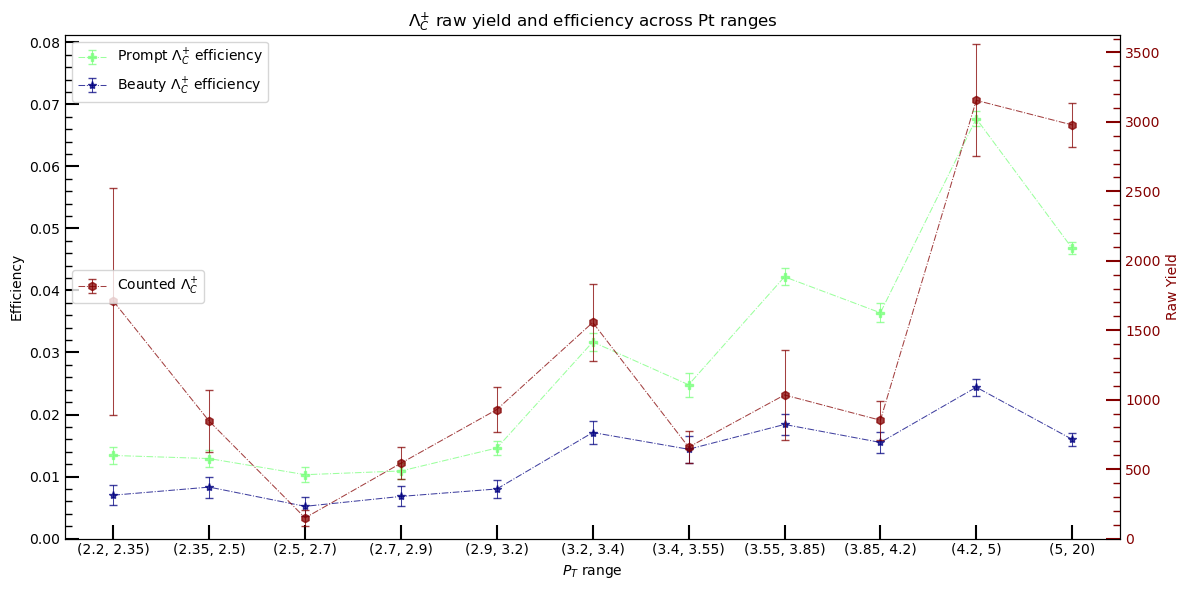

In [10]:
results_draw( p_name = p_name, pt_treshold = 1, results_df = results_df )

********************
Final results:

   - D_zero yield rate    : 3.994e-04 +- 5.33e-06 (Hz)
   - D_zero cross section : 8.899e-09 +- 1.19e-10 (ub)


   - Lambda_c+ yield rate    : 2.064e-04 +- 2.57e-05 (Hz)
   - Lambda_c+ cross section : 4.561e-09 +- 5.69e-10 (ub)


   - Lambda_c+ / D_zero ratio from corrected yield: 5.209e-01 +- 1.27e-02
   - Lambda_c+ / D_zero ratio from cross section: 5.126e-01 +- 6.43e-02

********************


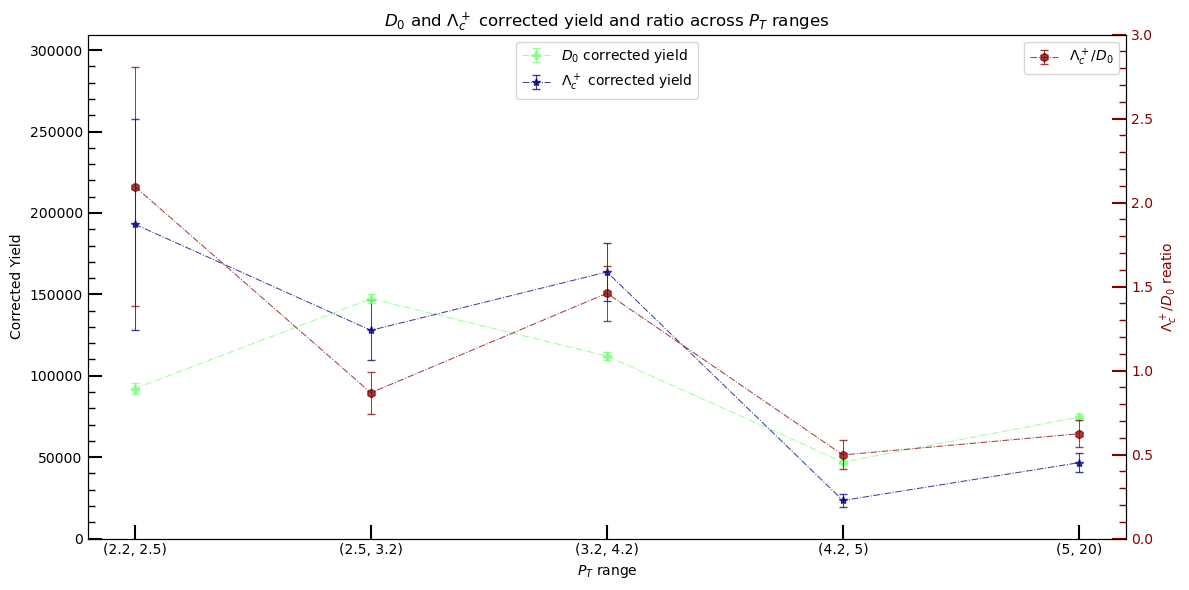

In [14]:
# having two different files for D0 and Lc results, now we can finally combine all and find their relative properties
D0_file = f"/mnt/CandidateReducedDF/Particle_D0_Counts.csv"
LC_file = f"/mnt/CandidateReducedDF/Particle_LC_Counts.csv"
D0_df = pd.read_csv( D0_file )
LC_df = pd.read_csv( LC_file )

common_path = "/mnt/CandidateTrees/Data"

D0_path = common_path + "/DzeroCandidate_LHC22o_pass7_minBias_small_2P3PDstar_hyp411512/AOD" 
LC_path = common_path + "/LcCandidate_LHC22o_pass7_minBias_small_2P3PDstar_hyp405295/AOD" 
collisions_tree = 'bc-selection-task/hCounterTVXafterBCcuts'
luminosity_tree = 'bc-selection-task/hLumiTVXafterBCcuts'
# selecting all data files uset to extract the yield ( first chunck used only for training )
files = [ f"/{i:03d}/AnalysisResults.root" for i in range( 2, 63 ) ]

total_D0_collisions = 0
total_D0_luminosity = 0
total_LC_collisions = 0
total_LC_luminosity = 0

for file in files :
    with ur.open( D0_path + file ) as f :
        total_D0_collisions += f[ collisions_tree ].values()[0]
        total_D0_luminosity += f[ luminosity_tree ].values()[0]
    with ur.open( LC_path + file ) as f :
        total_LC_collisions += f[ collisions_tree ].values()[0]
        total_LC_luminosity += f[ luminosity_tree ].values()[0]

# Plotting obtained raw yeld and yield ratio for different Pt ranges
# values to exlude due to wrong interpolation
D0_starting_pt = 2
LC_starting_pt = 1

# retrieving the data
D0_yield = D0_df[ 'Corrected Yield'].iloc[ D0_starting_pt : ].to_numpy()
D0_error = D0_df[ 'Sigma Corrected Yield'].iloc[ D0_starting_pt : ].to_numpy()
LC_yield = LC_df[ 'Corrected Yield'].iloc[ LC_starting_pt : ].to_numpy()
LC_error = LC_df[ 'Sigma Corrected Yield'].iloc[ LC_starting_pt : ].to_numpy()

# congregating different Dzero and LambdaC regions to get same pt intervals 
# for computational needs, we have to exclude results up to 2.2 Gev/c
D0_pt_subset = { 0 : [7],    # pt (2.2;2.5)
                 1 : [8,9],  # pt (2.5;3.2)
                 2 : [10],   # pt (3.2;4.2)
                 3 : [11],   # pt (4.2;5)
                 4 : [12]}   # pt (5;20)
LC_pt_subset = { 0 : [1,2],     # pt (2.2;2.5)
                 1 : [3,4,5],   # pt (2.5;3.2)
                 2 : [5,6,7,8], # pt (3.2;4.2)
                 3 : [9],       # pt (4.2;5)
                 4 : [10]}      # pt (5;20)
pt_subsets   = { 0 : (2.2, 2.5),
                 1 : (2.5, 3.2),
                 2 : (3.2, 4.2),
                 3 : (4.2, 5),
                 4 : (5, 20)}
D0_set = np.zeros( 5 )
D0_err = np.zeros( 5 )
LC_set = np.zeros( 5 )
LC_err = np.zeros( 5 )
for i in pt_subsets :
    D0_set[i] = np.sum([D0_yield[k-D0_starting_pt] for k in D0_pt_subset[i] ])
    D0_err[i] = np.sqrt(np.sum([ D0_error[k-D0_starting_pt]**2 for k in D0_pt_subset[i] ]))
    LC_set[i] = np.sum([LC_yield[k-LC_starting_pt] for k in LC_pt_subset[i] ])
    LC_err[i] = np.sqrt(np.sum([ LC_error[k-LC_starting_pt]**2 for k in LC_pt_subset[i] ]))
LC_D0 = LC_set / D0_set
LC_D0_err = LC_D0 * np.hypot( (D0_err/D0_set), (LC_err/LC_set) )

D0_yield_rate = D0_yield.sum() / total_D0_collisions
D0_rate_error = np.sqrt( np.sum( D0_error*D0_error ) )/ total_D0_collisions
D0_cross_section = D0_yield_rate / total_D0_luminosity
D0_c_s_error  = D0_rate_error / total_D0_luminosity

LC_yield_rate = LC_yield.sum() / total_LC_collisions
LC_rate_error = np.sqrt( np.sum( LC_error*LC_error ) )/ total_LC_collisions
LC_cross_section = LC_yield_rate / total_LC_luminosity
LC_c_s_error  = LC_rate_error / total_LC_luminosity

LC_D0_ratio = LC_yield.sum() / D0_yield.sum()
LC_D0_r_err = LC_D0_ratio * np.hypot( ( np.sum( D0_error*D0_error ) / np.sum(D0_yield*D0_yield) ), ( np.sum( LC_error*D0_error ) / np.sum(LC_yield*LC_yield) ) )

LC_D0_ratio_from_c_s = LC_cross_section / D0_cross_section
LC_D0_r_c_s_error = LC_D0_ratio_from_c_s * np.hypot( (LC_c_s_error/LC_cross_section), (D0_c_s_error/D0_cross_section))

print( '*'*20 )
print( f'Final results:\n\n   - D_zero yield rate    : {D0_yield_rate:.3e} +- {D0_rate_error:.2e} (Hz)\n   - D_zero cross section : {D0_cross_section:.3e} +- {D0_c_s_error:.2e} (ub)\n')
print( f'\n   - Lambda_c+ yield rate    : {LC_yield_rate:.3e} +- {LC_rate_error:.2e} (Hz)\n   - Lambda_c+ cross section : {LC_cross_section:.3e} +- {LC_c_s_error:.2e} (ub)\n')
print( f'\n   - Lambda_c+ / D_zero ratio from corrected yield: {LC_D0_ratio:.3e} +- {LC_D0_r_err:.2e}\n   - Lambda_c+ / D_zero ratio from cross section: {LC_D0_ratio_from_c_s:.3e} +- {LC_D0_r_c_s_error:.2e}\n')
print( '*'*20 )

N = 3
x = np.arange( len(pt_subsets) )
# define color and marker palette
colors  = plt.get_cmap( 'jet' )( np.arange( 3 ) / ( N - 0.99 ) )
markers = [ "*", "P", "h", "s", "d", "p", "8", "D", "v", "^", "<", ">" ]
    
fig, ax = plt.subplots( nrows = 1, ncols = 1, figsize = ( 12, 6 ) )
    
ax.errorbar( x = x, y = D0_set, yerr = D0_err, marker = markers[1],
             color = colors[1], label = r'$D_0$ corrected yield', alpha = 0.75, 
             markersize = 6, linestyle = '-.', capsize = 3, lw = 0.75 )
ax.errorbar( x = x, y = LC_set, yerr = LC_err, marker = markers[0], 
             color = colors[0], label = r'$\Lambda_c^+$ corrected yield', alpha = 0.75,
             markersize = 6, linestyle = '-.', capsize = 3, lw = 0.75 )
ax.set_ylim( 0.0, max((D0_set.max()+D0_err.max()), (LC_set.max()+LC_err.max()))*1.2 )
ax.xaxis.set_major_locator(MultipleLocator( 1 ))
ax.yaxis.set_minor_locator( AutoMinorLocator( 5 ) )
ax.set_xticks( x, labels = list(pt_subsets.values()) )
ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
ax.set_title( r"$D_0$ and $\Lambda_c^+$ corrected yield and ratio across $P_T$ ranges")
ax.set_xlabel( r"$P_T$ range")
ax.set_ylabel( "Corrected Yield", color='black')
ay = ax.twinx()        
ay.errorbar( x = x, y = LC_D0, yerr = LC_D0_err, marker = markers[2], 
             color = colors[2], label = r'$\Lambda_c^+/D_0$', alpha = 0.75, 
             markersize = 6, linestyle = '-.', capsize = 3, lw = 0.75 )
ay.set_ylabel( r'$\Lambda_c^+/D_0$ reatio', color = colors[2] )
ay.set_ylim( 0, int( (LC_D0.max()+LC_D0_err.max())*1.15 ) )
ay.tick_params( axis='y', labelcolor=colors[ 2 ] )
ay.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5, color = colors[2] )
ay.tick_params( which = 'minor', direction = 'in', length = 5, width = 1, color = colors[2] )
ay.yaxis.set_minor_locator( AutoMinorLocator( 5 ) )
ax.legend( loc = 'upper center')
ay.legend( loc = 'upper right')
fig.tight_layout()  
plt.show()

